# Milestone 1: Data Collection & Preprocessing
## Intelligent Support Ticket Classification with RAG

This notebook performs:
- Data loading
- Data validation
- Exploratory Data Analysis (EDA)
- Text merging
- Text cleaning
- Preparation of cleaned dataset for modeling


### 1 — Import Libraries

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import re
import nltk
from nltk.corpus import stopwords


### 2 — Load Dataset

In [3]:
data = pd.read_csv("../data/raw/tickets.csv")

print("Dataset Shape:", data.shape)
data.head()


Dataset Shape: (20000, 12)


,Ticket_ID,Customer_Name,Customer_Email,Ticket_Subject,Ticket_Description,Issue_Category,Priority_Level,Ticket_Channel,Submission_Date,Resolution_Time_Hours,Assigned_Agent,Satisfaction_Score
0,TKT-100000,George Simon,lisastrickland@example.com,Hours of operation - Individual,"Hi Support, Where is your headquarters located...",General Inquiry,High,Web Form,2025-07-02,43,David Kim,5
1,TKT-100001,Scott Thompson,wevans@example.org,Data not syncing - Card,"Hi Support, The application crashes every time...",Technical,High,Chat,2025-06-28,41,Elena Rodriguez,5
2,TKT-100002,Jennifer Smith,oleonard@example.net,2FA issues - Question,"Hi Support, How do I upgrade to the Enterprise...",Account,High,Web Form,2025-02-05,7,Anya Sharma,5
3,TKT-100003,Rachel Bullock,katherine67@example.net,Login failed - Let,"Hi Support, The dashboard is not loading any d...",Technical,Low,Web Form,2025-03-20,41,Anya Sharma,5
4,TKT-100004,Thomas Parks DDS,raykelsey@example.com,Refund status - Attention,"Hi Support, I have been trying to update my pa...",Billing,Medium,Email,2025-04-27,40,David Kim,5


### 3 — Data Overview

In [4]:
data.info()
data.isnull().sum()
print("Duplicate rows:", data.duplicated().sum())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   Ticket_ID              20000 non-null  object
 1   Customer_Name          20000 non-null  object
 2   Customer_Email         20000 non-null  object
 3   Ticket_Subject         20000 non-null  object
 4   Ticket_Description     20000 non-null  object
 5   Issue_Category         20000 non-null  object
 6   Priority_Level         20000 non-null  object
 7   Ticket_Channel         20000 non-null  object
 8   Submission_Date        20000 non-null  object
 9   Resolution_Time_Hours  20000 non-null  int64 
 10  Assigned_Agent         20000 non-null  object
 11  Satisfaction_Score     20000 non-null  int64 
dtypes: int64(2), object(10)
memory usage: 1.8+ MB
Duplicate rows: 0


### Dataset contains:
- 20,000 support tickets
- 12 columns
- No missing values
- No duplicate rows


### 4 — Drop Irrelevant Columns

#### Removing columns not required for text classification:
- Customer_Name
- Customer_Email
- Assigned_Agent
- Submission_Date
- Ticket_ID
- Satisfaction_Score


In [5]:
cols_to_drop = [
    "Customer_Name",
    "Customer_Email",
    "Assigned_Agent",
    "Submission_Date",
    "Ticket_ID",
    "Satisfaction_Score"
]

data = data.drop(columns=cols_to_drop)

print("New Shape:", data.shape)


New Shape: (20000, 6)


### 5 — Merge Text Columns

#### Combining Ticket_Subject and Ticket_Description
Creating a unified text field for NLP processing.


In [6]:
data["full_text"] = (
    data["Ticket_Subject"].astype(str) + " " +
    data["Ticket_Description"].astype(str)
)

data.head()


,Ticket_Subject,Ticket_Description,Issue_Category,Priority_Level,Ticket_Channel,Resolution_Time_Hours,full_text
0,Hours of operation - Individual,"Hi Support, Where is your headquarters located...",General Inquiry,High,Web Form,43,"Hours of operation - Individual Hi Support, Wh..."
1,Data not syncing - Card,"Hi Support, The application crashes every time...",Technical,High,Chat,41,"Data not syncing - Card Hi Support, The applic..."
2,2FA issues - Question,"Hi Support, How do I upgrade to the Enterprise...",Account,High,Web Form,7,"2FA issues - Question Hi Support, How do I upg..."
3,Login failed - Let,"Hi Support, The dashboard is not loading any d...",Technical,Low,Web Form,41,"Login failed - Let Hi Support, The dashboard i..."
4,Refund status - Attention,"Hi Support, I have been trying to update my pa...",Billing,Medium,Email,40,"Refund status - Attention Hi Support, I have b..."


### 6 — Text Length Analysis (EDA)

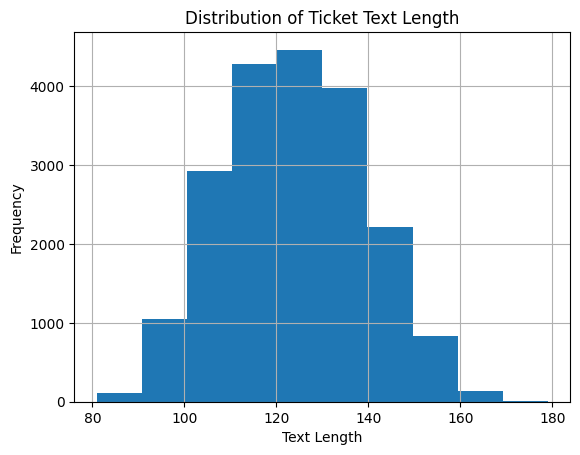

In [7]:
data["text_length"] = data["full_text"].apply(lambda x: len(str(x)))

plt.figure()
data["text_length"].hist()
plt.title("Distribution of Ticket Text Length")
plt.xlabel("Text Length")
plt.ylabel("Frequency")
plt.show()


### 7 — Class Distribution

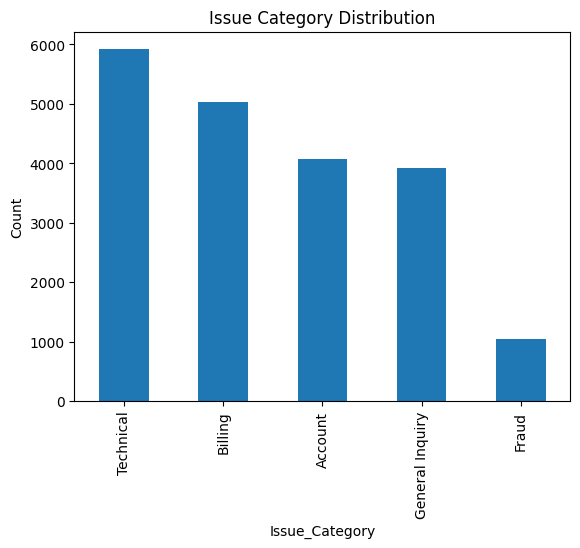

In [8]:
plt.figure()
data["Issue_Category"].value_counts().plot(kind="bar")
plt.title("Issue Category Distribution")
plt.ylabel("Count")
plt.show()


### 8 — Text Cleaning

#### Text Cleaning
- Lowercasing
- Removing special characters
- Removing stopwords


In [9]:
nltk.download("stopwords")
stop = set(stopwords.words("english"))

def clean_text(txt):
    txt = txt.lower()
    txt = re.sub(r"[^a-zA-Z0-9\s]", "", txt)
    txt = " ".join([w for w in txt.split() if w not in stop])
    return txt

data["clean_text"] = data["full_text"].apply(clean_text)

data.head()


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\aldawliahasbat\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


,Ticket_Subject,Ticket_Description,Issue_Category,Priority_Level,Ticket_Channel,Resolution_Time_Hours,full_text,text_length,clean_text
0,Hours of operation - Individual,"Hi Support, Where is your headquarters located...",General Inquiry,High,Web Form,43,"Hours of operation - Individual Hi Support, Wh...",112,hours operation individual hi support headquar...
1,Data not syncing - Card,"Hi Support, The application crashes every time...",Technical,High,Chat,41,"Data not syncing - Card Hi Support, The applic...",122,data syncing card hi support application crash...
2,2FA issues - Question,"Hi Support, How do I upgrade to the Enterprise...",Account,High,Web Form,7,"2FA issues - Question Hi Support, How do I upg...",108,2fa issues question hi support upgrade enterpr...
3,Login failed - Let,"Hi Support, The dashboard is not loading any d...",Technical,Low,Web Form,41,"Login failed - Let Hi Support, The dashboard i...",119,login failed let hi support dashboard loading ...
4,Refund status - Attention,"Hi Support, I have been trying to update my pa...",Billing,Medium,Email,40,"Refund status - Attention Hi Support, I have b...",124,refund status attention hi support trying upda...


### 9 — Final Dataset Selection

#### Keeping only necessary columns for modeling
- clean_text
- Issue_Category (Target)


In [10]:
final_data = data[["clean_text", "Issue_Category"]]

final_data.head()


,clean_text,Issue_Category
0,hours operation individual hi support headquar...,General Inquiry
1,data syncing card hi support application crash...,Technical
2,2fa issues question hi support upgrade enterpr...,Account
3,login failed let hi support dashboard loading ...,Technical
4,refund status attention hi support trying upda...,Billing


### 10 — Save Cleaned Dataset

#### Saving Cleaned Dataset

After preprocessing and cleaning the support tickets,
we save the cleaned corpus for further modeling and RAG pipeline development.

The cleaned dataset will be stored in:
data/interim/tickets_cleaned.csv


In [11]:
final_data.to_csv("../data/interim/tickets_cleaned.csv", index=False)
